In [1]:
import os
import torch
import pandas as pd
import scanpy as sc

In [2]:
import h5py
import anndata as ad
import pandas as pd
import numpy as np

# Open the custom HDF5 file
f = h5py.File('MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5', 'r')

# Extract metadata (convert byte strings to regular strings)
cell_names = [c.decode('utf-8') for c in f['Cell'][:]]
gene_names = [g.decode('utf-8') for g in f['Gene'][:]]
layer_names = [l.decode('utf-8') for l in f['LayerName'][:]]
spatial_coords = f['Pos'][:]

# 1. Create RNA AnnData object
adata_rna = ad.AnnData(X=f['X_RNA'][:])
adata_rna.obs_names = cell_names
adata_rna.var_names = gene_names
adata_rna.obs['Layertype'] = layer_names
adata_rna.obsm['spatial'] = spatial_coords

# 2. Create ATAC AnnData object
# Note: ATAC var_names are just PC/LSI dimensions (0 to 49) since it's already reduced
adata_atac = ad.AnnData(X=f['X_ATAC'][:])
adata_atac.obs_names = cell_names
adata_atac.obs['Layertype'] = layer_names
adata_atac.obsm['spatial'] = spatial_coords

# Close the file when done
f.close()

print("RNA Object:", adata_rna)
print("ATAC Object:", adata_atac)


RNA Object: AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype'
    obsm: 'spatial'
ATAC Object: AnnData object with n_obs × n_vars = 9215 × 50
    obs: 'Layertype'
    obsm: 'spatial'


In [3]:
# Path for Mouse Spleen
rna_path = 'data/Dataset11_Human_Lymph_Node_A1/adata_RNA.h5ad'
pro_path = 'data/Dataset11_Human_Lymph_Node_A1/adata_ADT.h5ad'

adata_omics1 = adata_rna.copy()
adata_omics2 = adata_atac.copy()

print("Data loaded successfully from the separate data folder!")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

print("variable named unique")

Data loaded successfully from the separate data folder!
variable named unique


In [4]:
# Specify data type
data_type = 'SPOTS'

# Fix random seed
from SpatialGlue.preprocess import fix_seed
random_seed = 2022
fix_seed(random_seed)

In [5]:
print(adata_omics1)
print()
print(adata_omics2)

AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype'
    obsm: 'spatial'

AnnData object with n_obs × n_vars = 9215 × 50
    obs: 'Layertype'
    obsm: 'spatial'


In [6]:
# Returns a DataFrame of n_obs × n_vars
df_X = adata_omics1.to_df()
df_X.head()


,Ppp1r14c,Mthfd1l,Gm25694,ENSMUSG00000096054,Vip,Lrp11,Katna1,Sash1,Utrn,B230208H11Rik,...,Syap1,Ctps2,Zrsr2,Bmx,Pir,Tceanc,Prps2,Msl3,Arhgap6,Erdr1
CTAAGGTCTTGCTGGA-1,-0.140865,-0.259024,-0.032993,-0.289554,-0.075714,-0.153061,-0.063516,-0.290688,-0.358486,-0.036583,...,-0.253146,-0.141995,-0.349409,-0.035598,-0.037720,-0.025670,-0.057784,-0.179132,-0.190409,-0.195177
CTAAGGTCACACAGAA-1,-0.168614,-0.026333,-0.014853,-0.340996,-0.092185,-0.193497,-0.063362,-0.188353,-0.353646,-0.005360,...,-0.149123,-0.077013,-0.365211,-0.043679,-0.038786,-0.024297,-0.059141,-0.171911,-0.236679,-0.182465
CTAAGGTCACAGCAGA-1,-0.180420,0.055892,-0.008830,-0.363402,-0.099315,-0.210335,-0.064289,-0.154110,-0.355699,0.005456,...,-0.113937,-0.055117,-0.374498,-0.047183,-0.039926,-0.024383,-0.060571,-0.171329,-0.255731,-0.180194
CTAAGGTCACCTCCAA-1,-0.195337,0.048003,-0.012368,-0.395864,-0.109107,-0.229357,-0.072012,-0.172997,-0.386346,0.002829,...,-0.130001,-0.065755,-0.403910,-0.051912,-0.045796,-0.028819,-0.067983,-0.187232,-0.275807,-0.198396
CTAAGGTCACGCTCGA-1,-0.175370,-0.242394,-0.038033,-0.361775,-0.098205,-0.197342,-0.079485,-0.314493,-0.419162,-0.037919,...,-0.271235,-0.154699,-0.410575,-0.046764,-0.050233,-0.034889,-0.073358,-0.210612,-0.237567,-0.230341


In [7]:
stats_df = adata_omics1.to_df().describe()
stats_df


,Ppp1r14c,Mthfd1l,Gm25694,ENSMUSG00000096054,Vip,Lrp11,Katna1,Sash1,Utrn,B230208H11Rik,...,Syap1,Ctps2,Zrsr2,Bmx,Pir,Tceanc,Prps2,Msl3,Arhgap6,Erdr1
count,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,...,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03,9.215000e+03
mean,2.159001e-17,-2.313216e-18,3.431270e-17,-9.252863e-18,-9.252863e-18,3.084288e-18,-1.310822e-17,7.710719e-18,5.860146e-17,2.313216e-17,...,1.233715e-17,4.703538e-17,-5.551718e-17,3.546931e-17,2.621644e-17,3.238502e-17,-2.891520e-17,6.939647e-18,-5.675089e-16,3.084288e-18
std,1.431668e+00,1.040953e+00,7.814356e-01,1.260033e+00,1.274135e+00,1.228625e+00,1.074596e+00,1.383548e+00,1.414702e+00,7.018689e-01,...,1.251136e+00,1.113835e+00,1.563379e+00,1.029029e+00,9.449259e-01,8.190681e-01,1.016089e+00,1.330089e+00,1.471581e+00,1.251558e+00
min,-3.544456e-01,-7.779514e-01,-7.974738e-02,-7.010181e-01,-2.172346e-01,-4.167538e-01,-1.659688e-01,-4.746273e-01,-6.986127e-01,-9.905301e-02,...,-4.282118e-01,-2.531985e-01,-6.870660e-01,-1.135135e-01,-1.229205e-01,-9.106435e-02,-1.585826e-01,-3.688392e-01,-4.720382e-01,-4.014504e-01
25%,-2.733902e-01,-1.552416e-01,-4.830503e-02,-5.390477e-01,-1.629901e-01,-3.211437e-01,-1.217386e-01,-3.433048e-01,-5.530838e-01,-3.680362e-02,...,-2.878325e-01,-1.707193e-01,-5.555238e-01,-8.070966e-02,-8.491755e-02,-6.027027e-02,-1.152732e-01,-2.872717e-01,-3.709001e-01,-3.123001e-01
50%,-2.492808e-01,-1.052369e-01,-4.097536e-02,-4.774276e-01,-1.474229e-01,-2.902342e-01,-1.094425e-01,-3.078967e-01,-4.995699e-01,-2.853000e-02,...,-2.563350e-01,-1.504046e-01,-5.067337e-01,-7.224582e-02,-7.491149e-02,-5.246379e-02,-1.034233e-01,-2.630649e-01,-3.377668e-01,-2.846371e-01
75%,-2.190124e-01,-5.953830e-02,-3.318972e-02,-3.217308e-01,-1.288893e-01,-2.480969e-01,-9.533667e-02,-2.645882e-01,-3.872280e-01,-1.995044e-02,...,-2.197503e-01,-1.273347e-01,-4.208330e-01,-6.269331e-02,-6.366215e-02,-4.379781e-02,-8.963620e-02,-2.318101e-01,-2.934466e-01,-2.482961e-01
max,1.751515e+01,1.756332e+01,1.754084e+01,1.746903e+01,1.753315e+01,1.755333e+01,1.753039e+01,1.751731e+01,1.603338e+01,1.754543e+01,...,1.750550e+01,1.754203e+01,1.746497e+01,1.753352e+01,1.754234e+01,1.753875e+01,1.753550e+01,1.749614e+01,1.748581e+01,1.749777e+01


In [8]:
import pandas as pd

# 1. Convert to DataFrame (if not already done)
df_rna = adata_omics1.to_df()

# 2. Calculate the average expression for every gene
gene_means = df_rna.mean().sort_values(ascending=False)

# 3. Calculate the maximum expression for every gene
gene_max = df_rna.max().sort_values(ascending=False)

print("--- Top 10 Genes by AVERAGE Expression ---")
print(gene_means.head(10))

print("\n--- Top 10 Genes by MAXIMUM Expression ---")
print(gene_max.head(10))


--- Top 10 Genes by AVERAGE Expression ---
Ahi1       1.865271e-16
Pde10a     1.819971e-16
Cst3       1.329256e-16
Tpt1       1.217872e-16
Akap9      1.142512e-16
Rfc1       1.109560e-16
Sparcl1    1.048176e-16
Arpp21     1.046007e-16
Rps14      1.044742e-16
Cox4i1     1.044080e-16
dtype: float64

--- Top 10 Genes by MAXIMUM Expression ---
Gpalpp1    17.600330
Abcg2      17.596167
Thumpd2    17.592573
Nde1       17.586382
Lrrc6      17.582948
Pin4       17.580564
Itga8      17.580078
Tbc1d2b    17.578531
Agk        17.577548
Fxyd5      17.577144
dtype: float64


In [9]:
# Returns a DataFrame of n_obs × n_vars
df_X = adata_omics2.to_df()
df_X.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
CTAAGGTCTTGCTGGA-1,-1.363344,-0.502771,-0.390093,1.463264,-0.144204,0.023235,-0.114998,0.628763,-0.421336,-2.759379,...,-0.248588,-0.166614,0.248306,-0.437401,0.188772,0.391727,-0.063994,-0.333538,-0.305202,-0.423545
CTAAGGTCACACAGAA-1,-2.159436,0.123428,-0.167970,-0.019623,-0.005727,-0.028177,-0.201303,0.124537,-0.035468,0.023205,...,-0.160596,0.055311,-0.038706,-0.093127,-0.187766,0.017571,-0.282408,0.068093,0.394567,-0.085592
CTAAGGTCACAGCAGA-1,-1.413220,-0.515318,-0.435810,0.560124,0.131865,0.123746,0.247051,0.090759,-0.305096,-1.403814,...,-0.416725,-0.271341,0.075278,0.109699,-0.115712,-0.564302,-0.443795,-0.084756,0.030576,-0.116429
CTAAGGTCACCTCCAA-1,-2.055290,-0.062291,-0.152210,-0.190086,0.005367,0.012779,-0.109562,-0.005786,0.154967,-0.056032,...,-0.132803,0.141207,0.188128,-0.031645,0.024844,0.146337,0.032433,0.072880,0.036406,0.100288
CTAAGGTCACGCTCGA-1,0.209806,0.759186,-0.623394,1.315017,1.416911,0.860191,-1.171489,0.288012,2.181422,1.730774,...,-1.300151,-0.158354,-0.702241,0.552188,-0.100034,0.491635,1.144871,-0.074201,-0.709733,-0.087764


# Preprocessing

In [10]:
from SpatialGlue.preprocess import clr_normalize_each_cell, pca

n_components = adata_omics2.n_vars - 1 
# RNA
adata_omics1.obsm['feat'] = pca(adata_omics1, n_comps=n_components)

# Protein
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=n_components)

# Constructing neighbour graph


In [11]:
from SpatialGlue.preprocess import construct_neighbor_graph
data = construct_neighbor_graph(adata_omics1, adata_omics2, datatype=data_type)

In [12]:
print (data)

{'adata_omics1': AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype'
    uns: 'adj_spatial'
    obsm: 'spatial', 'feat', 'adj_feature', 'adata_omics2': AnnData object with n_obs × n_vars = 9215 × 50
    obs: 'Layertype'
    uns: 'adj_spatial'
    obsm: 'spatial', 'feat', 'adj_feature'}


# MODEL

In [13]:
# Environment configuration. SpatialGlue pacakge can be implemented with either CPU or GPU. GPU acceleration is highly recommend for imporoved efficiency.
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
epoch_val=1000
# define model
from SpatialGlue.SpatialGlue_pyG import Train_SpatialGlue
model = Train_SpatialGlue(data, datatype=data_type, device=device, epochval=epoch_val)

# train model
output = model.train()


/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/preprocess.py:132: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:656.)
  return torch.sparse.FloatTensor(indices, values, shape)


epochval --> 1000


  0%|          | 0/1000 [00:00<?, ?it/s]/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/model.py:212: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(self.vu) + 1e-6)
  0%|          | 3/1000 [00:00<02:23,  6.94it/s]

Epoch 0 - Initial Loss: 13.9286


100%|██████████| 1000/1000 [01:09<00:00, 14.32it/s]


Model training finished! Final Loss: 8.4150



In [14]:
print(output)

{'emb_latent_omics1': array([[-0.04235503,  0.19524284,  0.21278639, ..., -0.02512833,
         0.13848276,  0.04038464],
       [-0.18878855, -0.08886607, -0.19294247, ..., -0.00218169,
        -0.125025  , -0.15405335],
       [-0.25445226, -0.19877374, -0.14873539, ..., -0.05883364,
        -0.08551673, -0.15182577],
       ...,
       [ 0.10770749, -0.04534852, -0.02245221, ...,  0.10368343,
         0.03191246, -0.01062981],
       [ 0.03236718, -0.06230477,  0.07041333, ...,  0.06377824,
         0.04143598, -0.00027469],
       [-0.12410741, -0.11923067,  0.12963134, ..., -0.02945152,
        -0.04455274, -0.12548321]], shape=(9215, 64), dtype=float32), 'emb_latent_omics2': array([[ 0.01446857, -0.08056894,  0.048627  , ...,  0.17186975,
         0.05751048,  0.06837565],
       [ 0.11369058, -0.10850438,  0.20984872, ...,  0.15872335,
         0.12746257,  0.14391969],
       [ 0.03354926, -0.09381347,  0.1141773 , ...,  0.26082885,
         0.00938794,  0.09023309],
       ...

In [15]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['SpatialGlue'] = output['SpatialGlue'].copy()
adata.obsm['alpha'] = output['alpha']
adata.obsm['alpha_omics1'] = output['alpha_omics1']
adata.obsm['alpha_omics2'] = output['alpha_omics2']

In [16]:
print(adata)

AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype'
    uns: 'adj_spatial'
    obsm: 'spatial', 'feat', 'adj_feature', 'emb_latent_omics1', 'emb_latent_omics2', 'SpatialGlue', 'alpha', 'alpha_omics1', 'alpha_omics2'


# Cross-omics integrative analysis

In [17]:
# we set 'mclust' as clustering tool by default. Users can also select 'leiden' and 'louvain'
from SpatialGlue.utils import clustering
tool = 'leiden' # mclust, leiden, and louvain
clustering(adata, key='SpatialGlue', add_key='SpatialGlue', n_clusters=9, method=tool, use_pca=True)

Searching resolution...


/Users/assadullahimran/developer/SpatialGlue_asad/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/utils.py:121: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


resolution=2.9899999999999984, cluster number=27


/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/utils.py:121: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


resolution=2.9799999999999986, cluster number=27


...

/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/utils.py:121: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


resolution=0.6499999999999997, cluster number=11


/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/utils.py:121: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


resolution=0.6399999999999997, cluster number=9


/Users/assadullahimran/developer/SpatialGlue_asad/SpatialGlue/utils.py:79: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


In [18]:
print(adata)

AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype', 'leiden', 'SpatialGlue'
    uns: 'adj_spatial', 'neighbors', 'leiden'
    obsm: 'spatial', 'feat', 'adj_feature', 'emb_latent_omics1', 'emb_latent_omics2', 'SpatialGlue', 'alpha', 'alpha_omics1', 'alpha_omics2', 'SpatialGlue_pca'
    obsp: 'distances', 'connectivities'


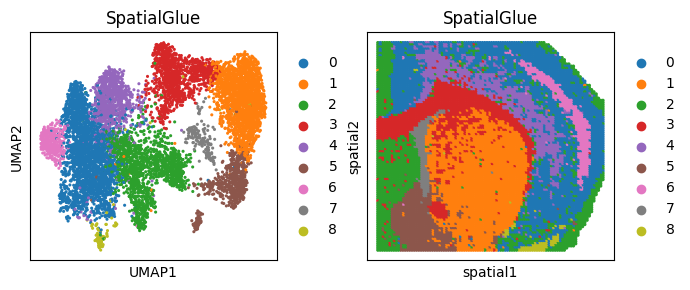

In [19]:
# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))
sc.pp.neighbors(adata, use_rep='SpatialGlue', n_neighbors=10)
sc.tl.umap(adata)

sc.pl.umap(adata, color='SpatialGlue', ax=ax_list[0], title='SpatialGlue', s=20, show=False)
sc.pl.embedding(adata, basis='spatial', color='SpatialGlue', ax=ax_list[1], title='SpatialGlue', s=25, show=False)

plt.tight_layout(w_pad=0.3)
plt.show()

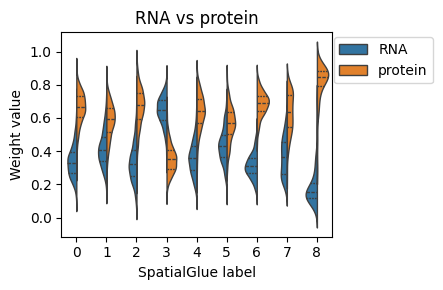

In [20]:
# plotting modality weight values.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5,3)
df = pd.DataFrame(columns=['RNA', 'protein', 'label'])
df['RNA'], df['protein'] = adata.obsm['alpha'][:, 0], adata.obsm['alpha'][:, 1]
df['label'] = adata.obs['SpatialGlue'].values
df = df.set_index('label').stack().reset_index()
df.columns = ['label_SpatialGlue', 'Modality', 'Weight value']
ax = sns.violinplot(data=df, x='label_SpatialGlue', y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
ax.set_title('RNA vs protein')
ax.set_xlabel('SpatialGlue label')
ax.legend(bbox_to_anchor=(1.4, 1.01), loc='upper right')

plt.tight_layout(w_pad=0.05)
plt.show()

In [21]:
print(adata.obs['Layertype'])

CTAAGGTCTTGCTGGA-1    1_others
CTAAGGTCACACAGAA-1       L1-L3
CTAAGGTCACAGCAGA-1       L1-L3
CTAAGGTCACCTCCAA-1       L1-L3
CTAAGGTCACGCTCGA-1       L1-L3
                        ...   
GAACAGGCGATGAATC-1    1_others
GAACAGGCGCCAAGAC-1    1_others
GAACAGGCCGGAAGAA-1    1_others
GAACAGGCGTGACAAG-1    1_others
GAACAGGCGAACCAGA-1    1_others
Name: Layertype, Length: 9215, dtype: category
Categories (9, object): ['1_others', 'ACB', 'CP', 'L1-L3', ..., 'L5', 'L6a/b', 'VL', 'ccg/aco']


In [22]:
print(adata.obs['leiden'])

CTAAGGTCTTGCTGGA-1    2
CTAAGGTCACACAGAA-1    2
CTAAGGTCACAGCAGA-1    2
CTAAGGTCACCTCCAA-1    2
CTAAGGTCACGCTCGA-1    0
                     ..
GAACAGGCGATGAATC-1    2
GAACAGGCGCCAAGAC-1    2
GAACAGGCCGGAAGAA-1    2
GAACAGGCGTGACAAG-1    2
GAACAGGCGAACCAGA-1    2
Name: leiden, Length: 9215, dtype: category
Categories (9, object): ['0', '1', '2', '3', ..., '5', '6', '7', '8']


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    v_measure_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

import scanpy as sc

In [24]:
from sklearn.metrics import adjusted_rand_score
y_true = adata.obs['Layertype'].astype(str)
y_pred = adata.obs['leiden'].astype(str)
ari = adjusted_rand_score(y_true, y_pred)

print("ARI Score: (Layertype)", ari)

ARI Score: (Layertype) 0.33677132220440104


In [25]:
# Ground truth
y_true = adata.obs['Layertype'].astype(str)

# Prediction (your model)
y_pred = adata.obs['leiden'].astype(str)

# Encode to integers (important for metrics stability)
le = LabelEncoder()
y_true_enc = le.fit_transform(y_true)
y_pred_enc = LabelEncoder().fit_transform(y_pred)

In [26]:
results = {}

results["ARI"] = adjusted_rand_score(y_true_enc, y_pred_enc)
results["NMI"] = normalized_mutual_info_score(y_true_enc, y_pred_enc)
results["AMI"] = adjusted_mutual_info_score(y_true_enc, y_pred_enc)
results["Homogeneity"] = homogeneity_score(y_true_enc, y_pred_enc)
results["V-measure"] = v_measure_score(y_true_enc, y_pred_enc)

print("===== MODEL EVALUATION =====")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

===== MODEL EVALUATION =====
ARI: 0.3368
NMI: 0.4814
AMI: 0.4804
Homogeneity: 0.4676
V-measure: 0.4814


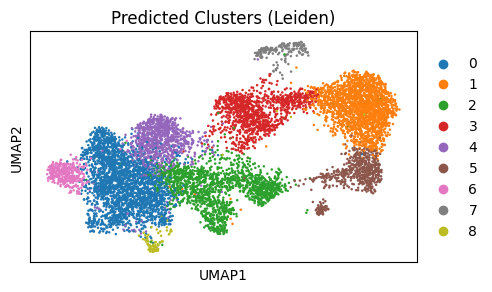

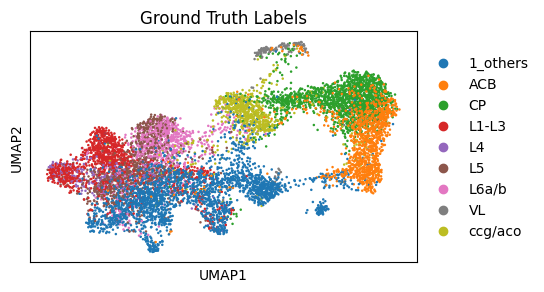

In [27]:
sc.pp.neighbors(adata, use_rep='SpatialGlue')
sc.tl.umap(adata)

sc.pl.umap(adata, color='leiden', title="Predicted Clusters (Leiden)")
sc.pl.umap(adata, color='Layertype', title="Ground Truth Labels")

/var/folders/pd/h31yy39534nc9ktbs0k57gf80000gn/T/ipykernel_23737/318884709.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


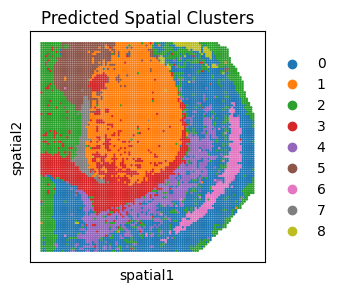

/var/folders/pd/h31yy39534nc9ktbs0k57gf80000gn/T/ipykernel_23737/318884709.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


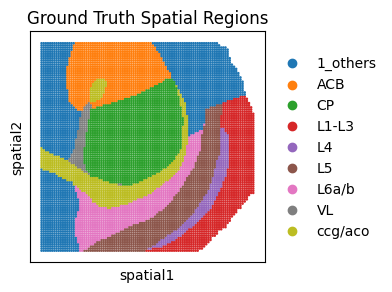

In [28]:
sc.pl.spatial(
    adata,
    color='leiden',
    title="Predicted Spatial Clusters",
    spot_size=1.2
)

sc.pl.spatial(
    adata,
    color='Layertype',
    title="Ground Truth Spatial Regions",
    spot_size=1.2
)

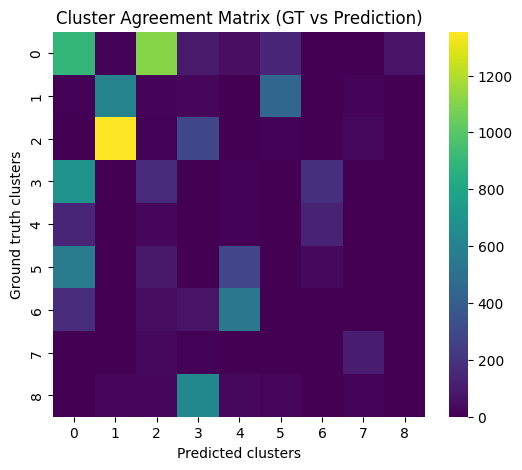

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_enc, y_pred_enc)

plt.figure(figsize=(6,5))
sns.heatmap(cm, cmap="viridis")
plt.title("Cluster Agreement Matrix (GT vs Prediction)")
plt.xlabel("Predicted clusters")
plt.ylabel("Ground truth clusters")
plt.show()

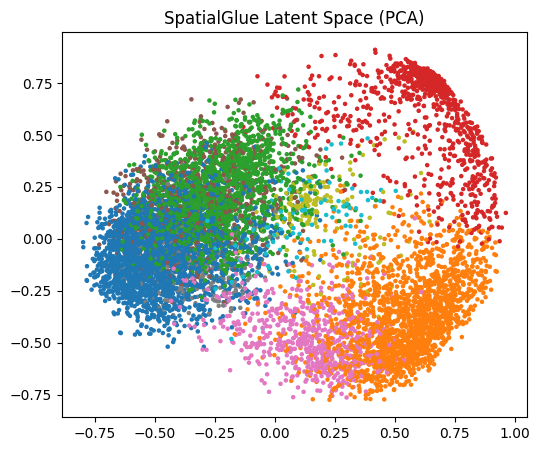

In [30]:
X = adata.obsm['SpatialGlue']

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_pred_enc, s=5, cmap="tab10")
plt.title("SpatialGlue Latent Space (PCA)")
plt.show()